<a href="https://colab.research.google.com/github/AnindyaNaura12/Data-Mining/blob/main/diabetes_jobsheet4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn import model_selection


In [10]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [11]:
data_raw = pd.read_csv('/content/drive/MyDrive/Kuliah/Data Mining/diabetes.csv')

In [12]:
# membuat salinan file agar file asli tidak berubah
data1 = data_raw.copy(deep=True)

In [13]:
#Mengecek jumlah null pada setiap kolom di dataset
print('Kolom data Diabetes dengan nilai NULL:\n', data1.isnull().sum())
print("-"*10)

data_raw.describe(include = 'all')


Kolom data Diabetes dengan nilai NULL:
 Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64
----------


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [15]:
#Merubah nilai 0 menjadi null/nan agar dapat direplace missing value
cols = ['Glucose','BloodPressure','SkinThickness','Insulin','BMI','Age']
data1[cols] = data1[cols].replace(0, np.nan)

In [16]:
print('Kolom data Diabetes dengan nilai NULL:\n', data1.isnull().sum())
print("-"*10)

data_raw.describe(include = 'all')

Kolom data Diabetes dengan nilai NULL:
 Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64
----------


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [18]:
#mengisi atribut yang kosong dengan median
for col in cols:
    #isikan atribut yang kosong dengan median
    data1[col].fillna(data1[col].median(), inplace = True)

print(data1.isnull().sum())
print("-"*10)

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64
----------


/tmp/ipykernel_855/2286170987.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data1[col].fillna(data1[col].median(), inplace = True)


In [42]:
#membagi umur menjadi 5 kelompok
data1['AgeBin'] = pd.cut(
    data1['Age'],
    bins=[20,30,45,60,100],
    labels=['Young','Adult','Middle Age','Senior']
)

#membagi bmi menjadi beberapa kategori
data1['BMICategory'] = pd.cut(data1['BMI'],
                          bins=[0,18.5,25,30,100],
                          labels=['Underweight','Normal','Overweight','Obese'])

#membagi kadar gula menjadi 4 kelompok
data1['GlucoseBin'] = pd.cut(
    data1['Glucose'],
    bins=[0,100,126,200,300],
    labels=['Normal','Prediabetes','Diabetes','Severe']
)

print(data1[['Age','AgeBin']].head())
print(data1[['BMI','BMICategory']].head())
print(data1[['Glucose','GlucoseBin']].head())

   Age      AgeBin
0   50  Middle Age
1   31       Adult
2   32       Adult
3   21       Young
4   33       Adult
    BMI BMICategory
0  33.6       Obese
1  26.6  Overweight
2  23.3      Normal
3  28.1  Overweight
4  43.1       Obese
   Glucose GlucoseBin
0    148.0   Diabetes
1     85.0     Normal
2    183.0   Diabetes
3     89.0     Normal
4    137.0   Diabetes


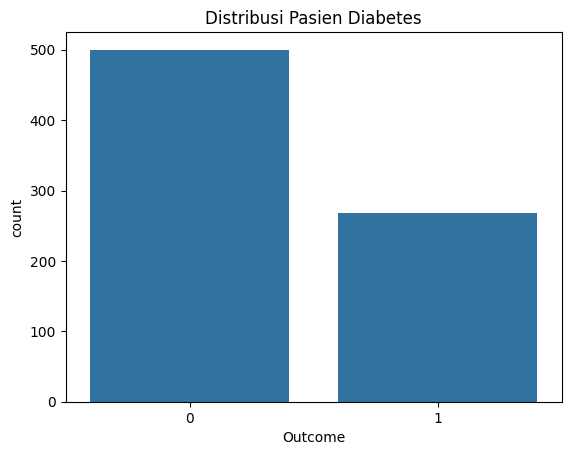

In [20]:
# melihat perbandingan jumlah pasien diabetes dan tidak diabetes
sns.countplot(x='Outcome', data=data1)
plt.title('Distribusi Pasien Diabetes')
plt.show()

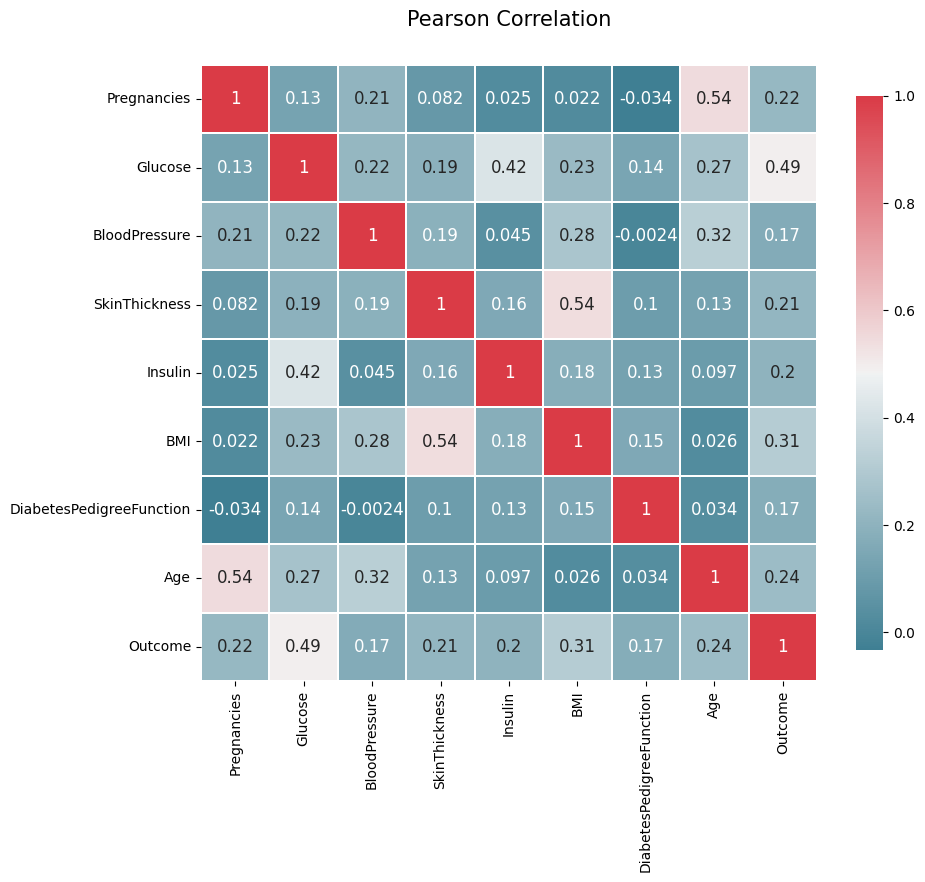

In [45]:
#Korelasi heatmap dari dataset
def correlation_heatmap(df):
  _ , ax = plt.subplots(figsize =(10, 8))
  colormap = sns.diverging_palette(220, 10, as_cmap = True)

  # Hanya dipilih fitur numerik saja
  numerical_df = df.select_dtypes(include=['number'])

  _ = sns.heatmap(
      numerical_df.corr(),
      cmap = colormap,
      square=True,
      cbar_kws={'shrink' :.9 },
      ax=ax,
      annot=True,
      linewidths=0.1, vmax=1.0, linecolor='white',
      annot_kws={'fontsize' :12 }
  )

  plt.title('Pearson Correlation', y=1.05, size=15)

correlation_heatmap(data1)

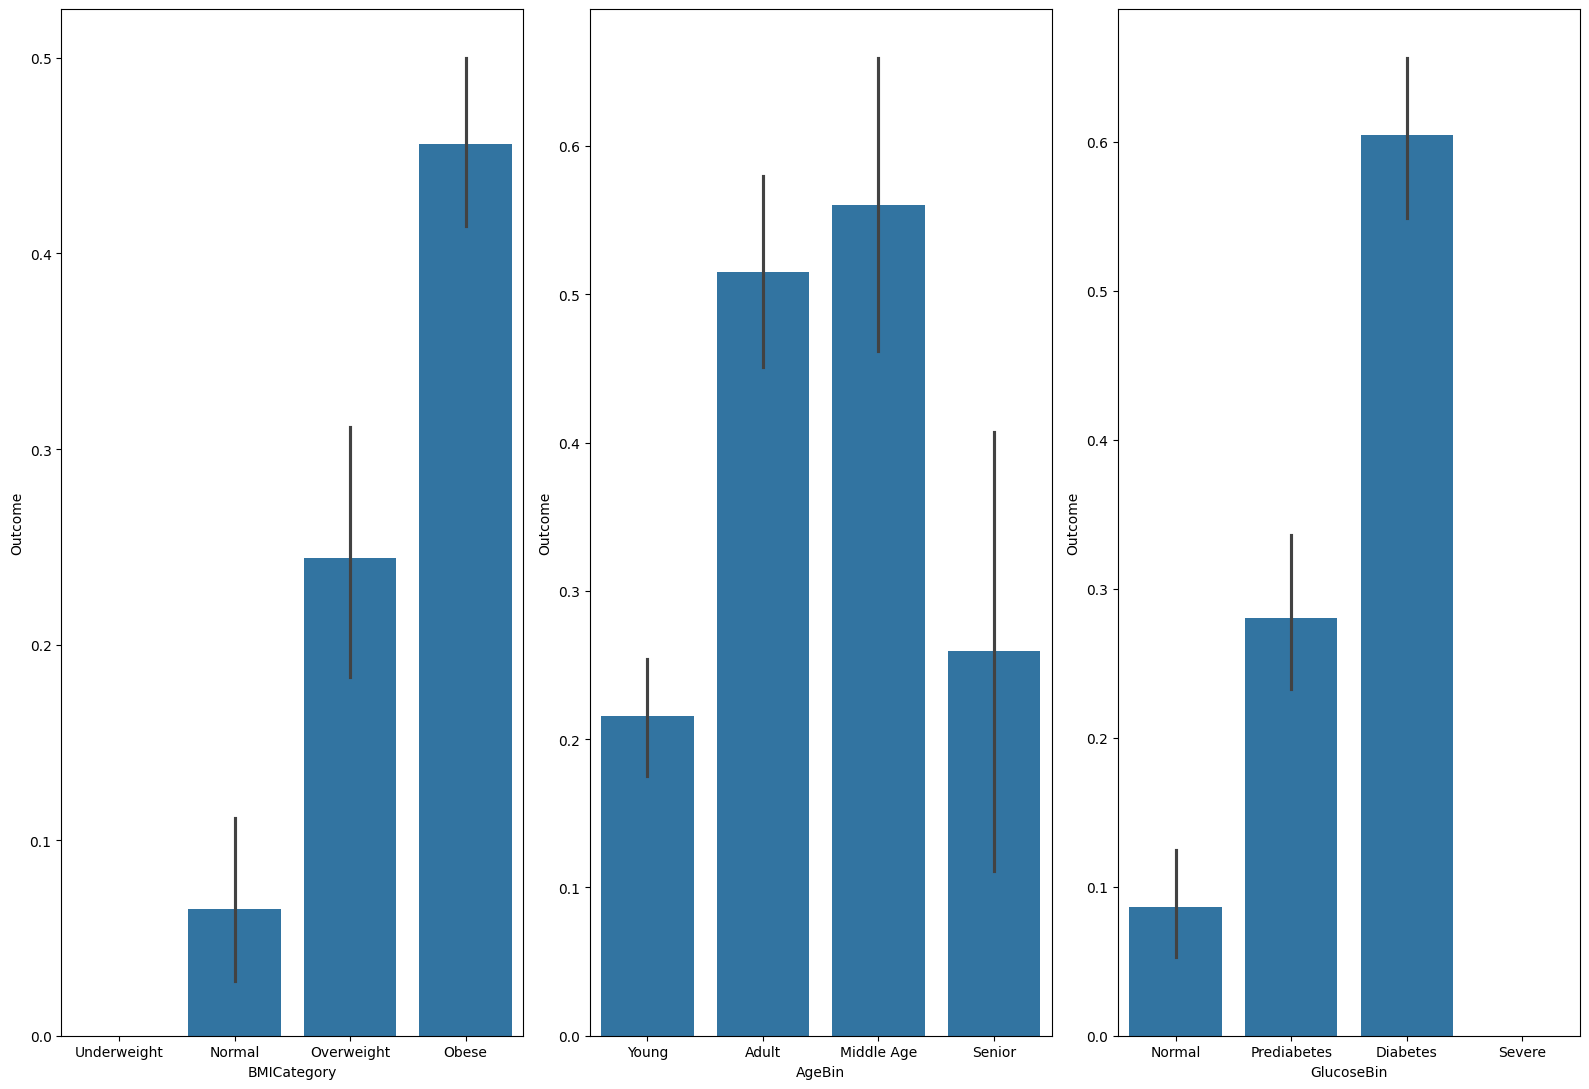

In [43]:
fig, saxis = plt.subplots(1, 3, figsize=(16,11))

sns.barplot(x='BMICategory', y='Outcome', data=data1, ax=saxis[0])
sns.barplot(x='AgeBin', y='Outcome', data=data1, ax=saxis[1])
sns.barplot(x='GlucoseBin', y='Outcome', data=data1, ax=saxis[2])

plt.tight_layout()
plt.show()

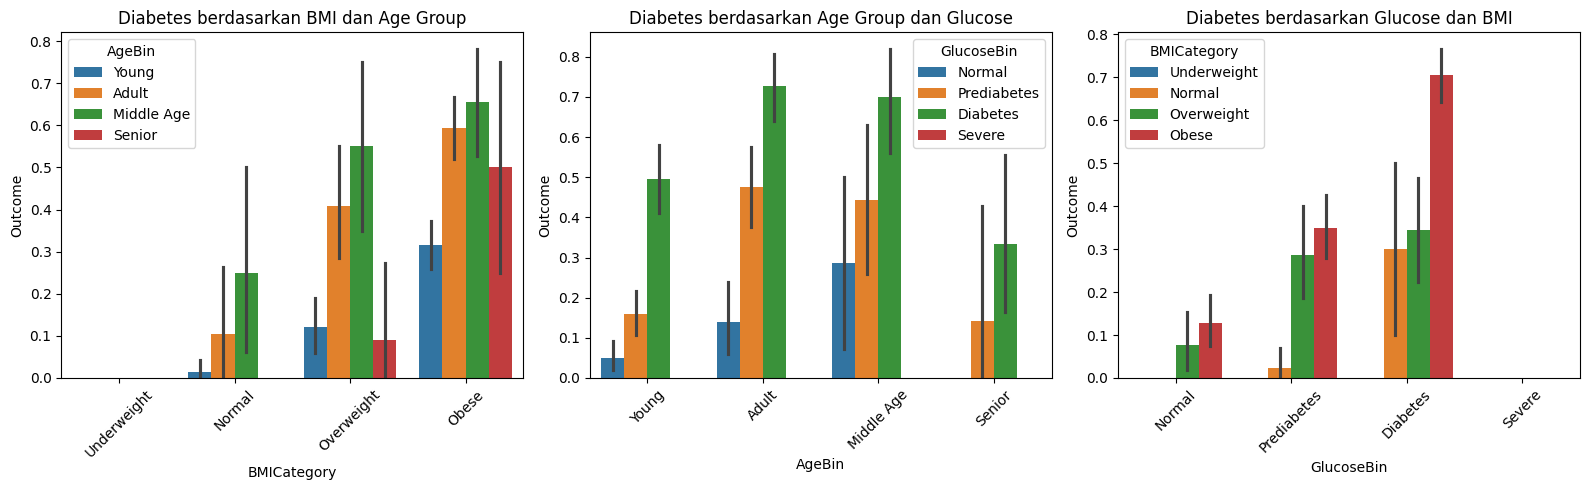

In [47]:
fig, qaxis = plt.subplots(1, 3, figsize=(16,5))

sns.barplot(x='BMICategory', y='Outcome', hue='AgeBin', data=data1, ax=qaxis[0])
qaxis[0].set_title('Diabetes berdasarkan BMI dan Age Group')

sns.barplot(x='AgeBin', y='Outcome', hue='GlucoseBin', data=data1, ax=qaxis[1])
qaxis[1].set_title('Diabetes berdasarkan Age Group dan Glucose')

sns.barplot(x='GlucoseBin', y='Outcome', hue='BMICategory', data=data1, ax=qaxis[2])
qaxis[2].set_title('Diabetes berdasarkan Glucose dan BMI')

for ax in qaxis:
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()